In [1]:
#######################################################################################################
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import os
import sys

# Get the current notebook's directory
notebook_dir = os.path.abspath('')
# Add the relative path to your Codes directory
codes_path = os.path.join(notebook_dir, "..", "Codes")
codes_path = os.path.abspath(codes_path)  # Normalize the path
# Add to path if not already there
if codes_path not in sys.path:
    sys.path.insert(1, codes_path)
from myUtils import *

MAINPATH is set to: /home/emanuele/Research/APES/FHN/


In [2]:
# Distance to forest
PATHFD = os.path.join(MAINPATH,"Data/LANDUSE/hilda_mollweide/distanceToForest/forest_{year}_mollweide_dist", "forest_{year}_mollweide_dist.tif")  # Forest distance
# Population
PATHP = os.path.join(MAINPATH, "Data/POPULATION/", "GHS_POP_E{year}_GLOBE_R2023A_54009_1000_V1_0/GHS_POP_E{year}_GLOBE_R2023A_54009_1000_V1_0.tif")


In [3]:
# Custom regions shapefiles 
shapef = os.path.join(MAINPATH, 'Data/SHAPEFILES/world-custom_regions_r.shp')
gdf1 = gpd.read_file(shapef)
gdf1 = gdf1.to_crs("ESRI:54009")
YEARS = np.arange(1975, 2025, 5)

In [4]:
# Process each year once
results = []
for year in YEARS:
    # Read rasters only once per year
    d_raster_path = PATHFD.format(year=year)  # distance file 
    p_raster_path = PATHP.format(year=year)  # population population file
    
    # Read raster data once per year
    srcd = rasterio.open(d_raster_path)
    srcp = rasterio.open(p_raster_path)
    
    # Process each region
    for index, region in gdf1.iterrows():
        
        # Get geometry once
        geometry = [region['geometry']]
        
        # Apply mask for distance data
        masked_d, _ = mask(srcd, geometry, crop=True)
        masked_d = -masked_d
        # Apply mask for population data
        masked_p, _ = mask(srcp, geometry, crop=True)
        # Clean population data (replace negative values with 0)
        masked_p[masked_p < 0] = 0
        
        # Calculate total population in region
        total_pop = np.nansum(masked_p)
        
        # Apply distance threshold (<=5km to forest)
        masked_p[masked_d > 5] = 0
        forest_prox_pop = np.nansum(masked_p)
        
        # Get region name
        region_name = region['custom_reg'] if 'custom_reg' in region else index
        
        
        print(region_name, year, total_pop, forest_prox_pop)
        # Store result with all metadata
        results.append({
            'FPP': forest_prox_pop,  # Population within 5km of forest
            'POP': total_pop,        # Total population in region
            'Region': region_name,   # Region identifier
            'Year': year             # Year of analysis
        })


Central Asia 1975 36430756.37494129 4773454.575730915
Eastern Africa 1975 123002275.5509339 71960366.75252733
Eastern Asia 1975 1094755040.2387974 454283820.1886424
Eastern Europe 1975 284203910.98647255 189392612.7662475
Middle Africa 1975 50075484.36257611 32641974.71535145
Northern Africa 1975 92200035.02721915 23552900.28500941
Northern America 1975 335310486.01178014 208235254.173253
Northern Europe 1975 85783178.52531035 43839493.32584193
Oceania 1975 20179252.537749607 12721676.01652212
South America 1975 212830983.12320513 131971677.42762706
South-Eastern Asia 1975 304469439.48800665 101226036.4546731
Southern Africa 1975 29027873.75780704 15725707.384950807
Southern Asia 1975 827951431.0645547 215851488.9467247
Southern Europe 1975 129834756.67439002 60537873.54186413
Western Africa 1975 120229479.2401658 53747310.19152945
Western Asia 1975 99049295.47401932 29496956.594279096
Western Europe 1975 167422248.19532588 113855047.31699552
Central Asia 1980 40738793.34255113 5403666

In [5]:
df = pd.DataFrame(results)
df.to_csv(os.path.join(MAINPATH, 'Data', 'OUTPUT', 'FPP','df_5_regions_ok.csv' ), index=None)

In [7]:
DF_all = df.copy()
DF_all['FPP_rel'] = DF_all['FPP'] / DF_all['POP']

In [39]:
REGIONS = DF_all['Region'].unique()
results_list = []
col_to_plot = 'FPP_rel'
# For each region, plot data and calculate Sen's slope
for i, region in enumerate(REGIONS):
    df_region = DF_all[DF_all["Region"] == region].sort_values("Year")
    
    # Extract x and y data
    x = df_region['Year'].values
    y = df_region[col_to_plot].values
    
    # Plot the original data
    
    # Calculate the trend line using Sen's slope
    y_start = y[0]
    y_end = y[-1]
    slope = 100*(y_end - y_start) / y_start
    print(slope, region)
    
    # Add results to list
    results_list.append({
        'Region': region,
        'Slope': slope,
    })

# Create a results dataframe
results_df = pd.DataFrame(results_list)

106.96960594667152 Central Asia
-19.87392414992202 Eastern Africa
4.97817562532006 Eastern Asia
12.039188983269783 Eastern Europe
-39.562152307517344 Middle Africa
-14.028509969447159 Northern Africa
4.1940789613758716 Northern America
56.74204189549967 Northern Europe
4.8630164963707285 Oceania
-8.361753625275197 South America
7.927187443116974 South-Eastern Asia
-27.987757173985475 Southern Africa
17.401501627763583 Southern Asia
37.863042393296105 Southern Europe
-19.42123776140994 Western Africa
-4.0100923385379055 Western Asia
19.581862708314468 Western Europe


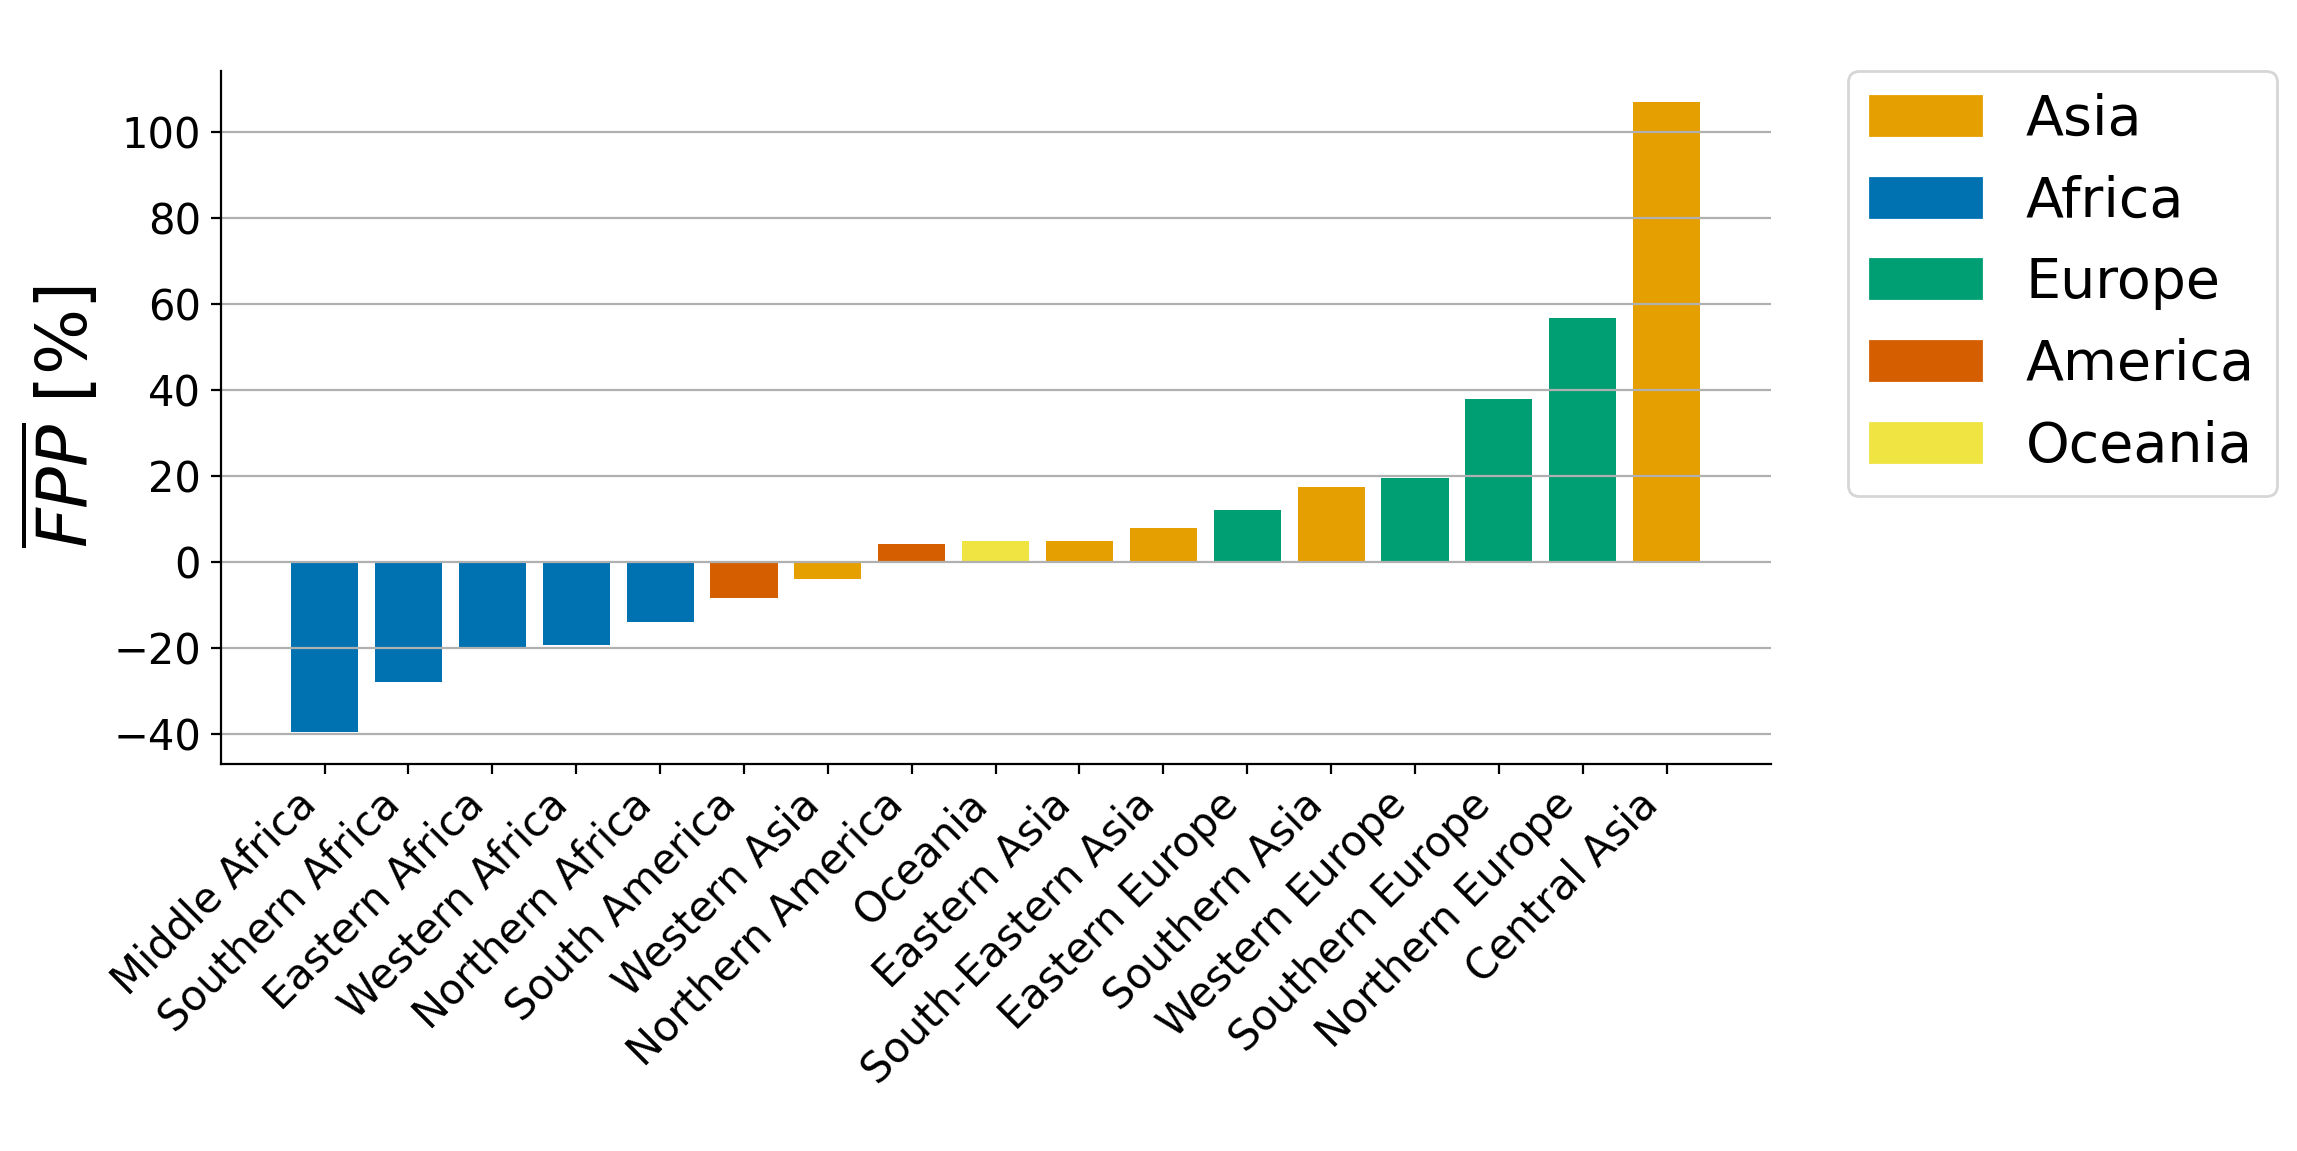

In [16]:
results_df = results_df.sort_values('Slope')
colors = results_df['Region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)
# Plotting the bar plot
f, ax = plt.subplots(figsize=(10, 4.5))
ax = set_font(ax, 15)
plt.bar(results_df['Region'], results_df['Slope'], color=colors)
# Adding labels and title
plt.xlabel(' ')
plt.ylabel(r'$\overline{FPP}$ [%]', size=25)
plt.title(' ', size=16)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Creating legend patches
patches = [mpatches.Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
# Adding the legend outside the plot
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
plt.xticks(rotation=45, ha='right');

In [19]:
fout = '../Figures/FPP_relchange.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')

In [28]:
def detect_turning_points(years, values, slope_threshold=0.5):
    """
    Detect turning points in a time series where the slope changes significantly.
    
    Parameters:
    - years: array of years (x-values)
    - values: array of measurements (y-values)
    - slope_threshold: minimum absolute difference in slopes to consider a turning point
    
    Returns:
    - turning_points: indices of detected turning points
    - turning_years: years where turning points occur
    - turning_values: values at turning points
    """
    # Calculate time intervals
    time_intervals = np.diff(years)
    
    # Calculate slopes between consecutive points
    slopes = np.diff(values) / time_intervals
    
    turning_points = []
    # Start from the second point and end at the second-to-last point
    for i in range(1, len(slopes)):
        # Calculate slope difference
        slope_diff = slopes[i] - slopes[i-1]
        
        # Check for sign change
        sign_change = (slopes[i-1] > 0 and slopes[i] < 0) or (slopes[i-1] < 0 and slopes[i] > 0)
        
        # Handle the case where one slope is exactly zero
        if slopes[i-1] == 0 or slopes[i] == 0:
            sign_change = True
        
        # Check if slope exceeds threshold and changes sign
        if sign_change and (abs(slope_diff) > slope_threshold):
            # The turning point is at index i in the original series
            turning_points.append(i)
    
    turning_years = years[turning_points]
    turning_values = values[turning_points]
    
    return turning_points, turning_years, turning_values

In [23]:
# Define the fixed number of rows (continents)
continent_order = ["Africa", "Asia", "America", "Oceania", "Europe"]
rows = len(continent_order)
DF_all["Continent"] = DF_all["Region"].map(REGION_TO_CONTINENT)
# Get unique regions per continent
regions_by_continent = {continent: DF_all[DF_all["Continent"] == continent]["Region"].unique() \
                        for continent in continent_order}
# Determine the maximum number of columns based on the continent with the most regions
cols = max(len(regions) for regions in regions_by_continent.values())

In [27]:
for region in REGIONS:
    # Get indices and sorted data for this region
    region_indices = DF_all[DF_all["Region"] == region].index
    df_region = DF_all[DF_all["Region"] == region].sort_values("Year").reset_index(drop=True)
    
    if len(df_region) > 0:  # Add safety check
        # Calculate relative change
        signal = df_region['FPP_rel'].values
        baseline = signal[0]
        if baseline != 0:  # Add safety check for division by zero
            signal = 100 * (signal - baseline) / baseline
            # Update values in original DataFrame
            DF_all.loc[region_indices, 'FPP_rel_relative'] = signal

Eastern Africa: found 0 turning points
Middle Africa: found 0 turning points
Northern Africa: found 1 turning points
Southern Africa: found 1 turning points
Western Africa: found 0 turning points
Central Asia: found 3 turning points
Eastern Asia: found 3 turning points
South-Eastern Asia: found 4 turning points
Southern Asia: found 2 turning points
Western Asia: found 2 turning points
Northern America: found 2 turning points
South America: found 2 turning points
Oceania: found 4 turning points
Eastern Europe: found 1 turning points
Northern Europe: found 5 turning points
Southern Europe: found 2 turning points
Western Europe: found 0 turning points


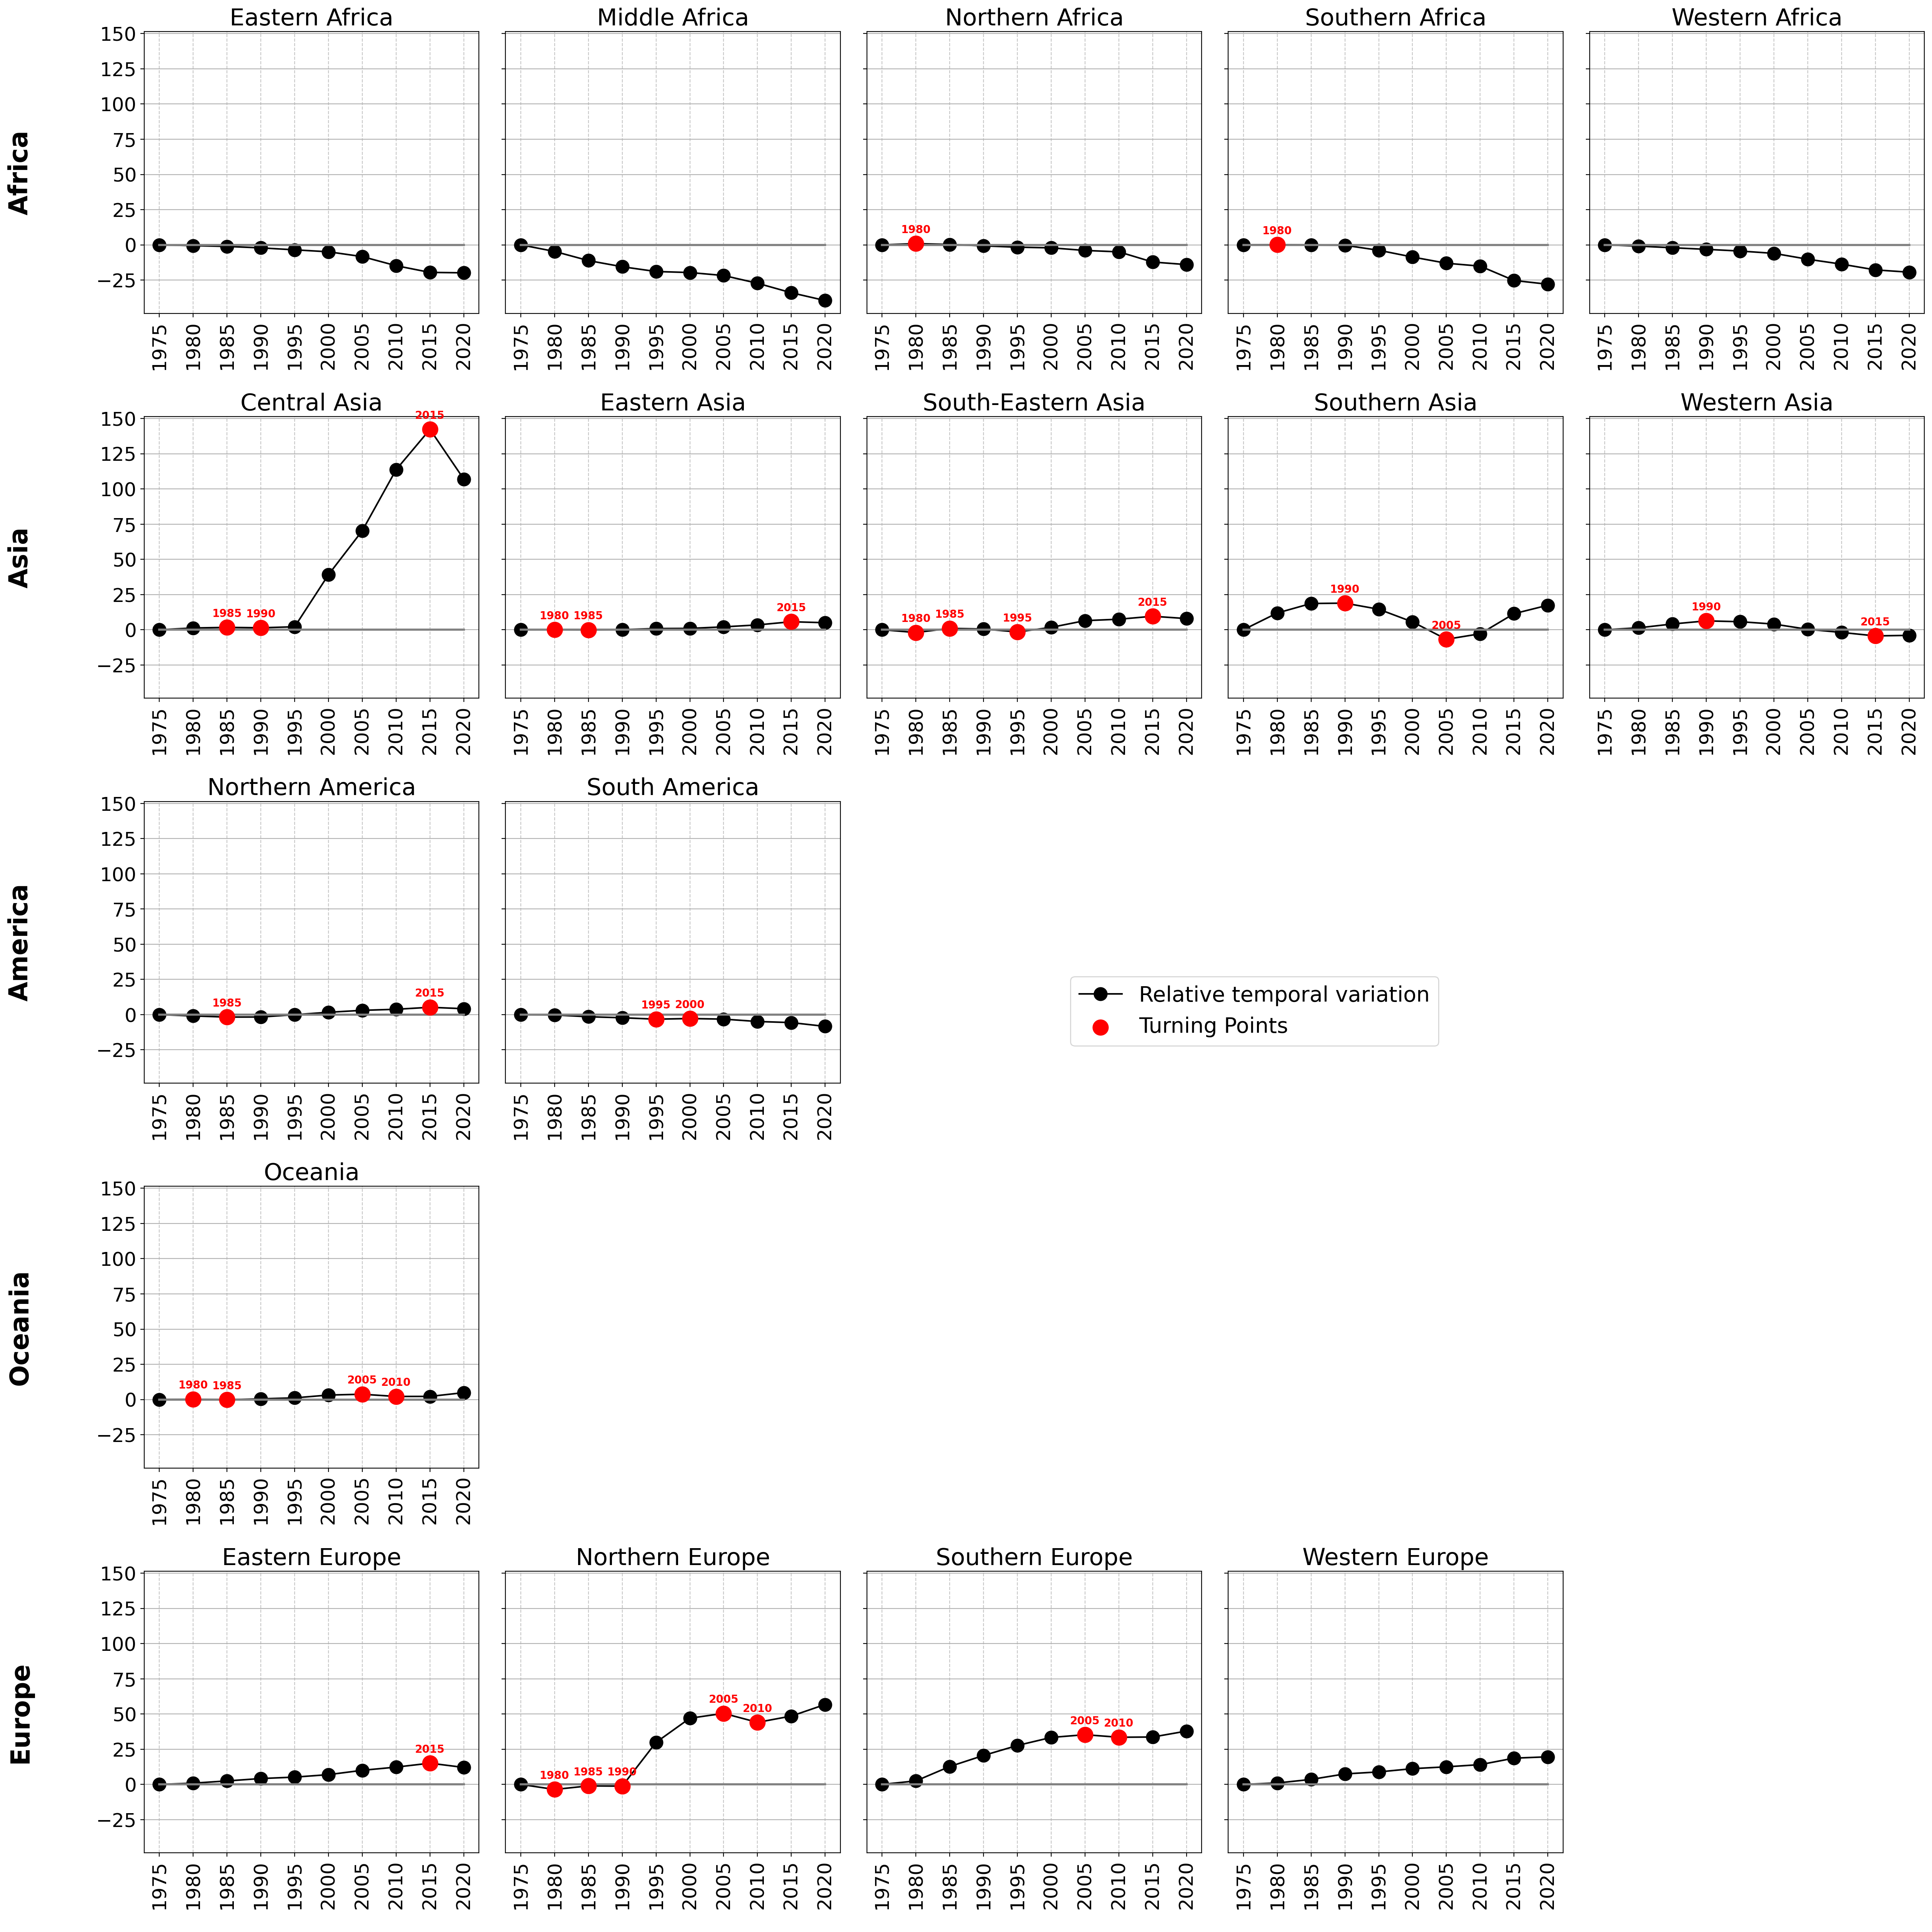

In [29]:
col_to_plot = 'FPP_rel_relative'

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), 
                         constrained_layout=True, sharex=False, sharey=True)
# Ensure axes is a 2D array
if rows == 1:
    axes = np.expand_dims(axes, axis=0)
if cols == 1:
    axes = np.expand_dims(axes, axis=1)
    
# Dictionary to store unique legend handles and labels
unique_handles = {}    

# Iterate over continents and regions to populate the subplots
for row_idx, continent in enumerate(continent_order):
    regions = regions_by_continent[continent]
    for col_idx, region in enumerate(regions):
        ax = axes[row_idx, col_idx]  # Get the corresponding subplot
        ax = set_font(ax, 18)
        
        # Get data for this region
        df_region = DF_all[DF_all["Region"] == region].sort_values("Year")
        
        # Calculate turning points
        slope_threshold = 0.001  # Adjust as needed
        years = df_region['Year'].values
        values = df_region[col_to_plot].values
        
        indices, turning_years, turning_values = detect_turning_points(years, values, slope_threshold)
        print(f"{region}: found {len(turning_years)} turning points")
        
        # Plot the main line
        line1, = ax.plot(df_region["Year"], df_region[col_to_plot], marker="o", 
                         markersize=12, color="black", label="Relative temporal variation")
        
        # Plot the zero reference line
        line2, = ax.plot([1975, 2020], [0, 0], lw=2, color='gray')
        
        # Plot turning points with higher z-order to ensure visibility
        if len(turning_years) > 0:
            tp_scatter = ax.scatter(turning_years, turning_values, color='red', 
                                   s=200, zorder=10, label='Turning Points')
            unique_handles['Turning Points'] = tp_scatter
            
            # Optional: Add text labels for turning points
            for year, value in zip(turning_years, turning_values):
                ax.annotate(f"{year}", (year, value), xytext=(0, 10), 
                           textcoords='offset points', ha='center', color='red', fontweight='bold')
        
        # Store handles for legend
        unique_handles['Relative temporal variation'] = line1
        
        # Set labels and title
        ax.set_xlabel(" ")
        ax.set_ylabel(" ")
        ax.set_title(region, size=22)
        ax.grid(True)
        
    # Hide unused subplots in this row
    for col_idx in range(len(regions), cols):
        fig.delaxes(axes[row_idx, col_idx])

# Set row labels (continent names)
for row_idx, continent in enumerate(continent_order):
    ax = axes[row_idx, 0]
    ax.set_ylabel(f"{continent}\n\n ", fontsize=24, fontweight="bold")

# Place the legend outside the plot
fig.legend(unique_handles.values(), unique_handles.keys(),
           bbox_to_anchor=(0.65, 0.5),  # Adjust position as needed
           loc='upper center', ncol=len(unique_handles)-1, fontsize=20)

# Set x-axis ticks
all_years = np.arange(1975, 2021, 5)
for ax in axes.flatten():
    if ax.get_subplotspec().get_geometry()[2] < rows * cols:  # Check if not deleted
        ax.set_xticks(all_years)
        ax.set_xticklabels(all_years, rotation=90)
        ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.7)

plt.show()

In [30]:
fout = '../Figures/FPP_trends_regions.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')

In [32]:
import pymannkendall as mk  # Use pymannkendall for Sen's slope and Mann-Kendall test
import seaborn as sns
from scipy import stats

results_list = []
# For each region, plot data and calculate Sen's slope
for i, region in enumerate(REGIONS):
    df_region = DF_all[DF_all["Region"] == region].sort_values("Year")
    
    # Extract x and y data
    x = df_region['Year'].values
    y = df_region[col_to_plot].values
    
    # Plot the original data
    
    # Run Mann-Kendall test and Sen's slope analysis
    mk_result = mk.original_test(y, alpha=0.05)
    
    # Get the slope
    slope = mk_result.slope

    # Calculate the trend line using Sen's slope
    y_start = mk_result.intercept + mk_result.slope * x[0]
    y_end = mk_result.intercept + mk_result.slope * x[-1]

    # Get significance stars
    significance = ''
    if mk_result.p < 0.001:
        significance = '***'
    elif mk_result.p < 0.01:
        significance = '**'
    elif mk_result.p < 0.05:
        significance = '*'
    else:
        significance = 'ns'
    
    # Add results to list
    results_list.append({
        'Region': region,
        'Slope': slope,
        'p-value': mk_result.p,
        'Significance': significance,
        'Trend': mk_result.trend,
        'Intercept': mk_result.intercept
    })

# Create a results dataframe
results_df1 = pd.DataFrame(results_list)

In [34]:
results_df1 = results_df1.sort_values('Slope').reset_index(drop=True)
results_df1

,Region,Slope,p-value,Significance,Trend,Intercept
0,Middle Africa,-4.002006,0.000083,***,decreasing,-1.299908
1,Southern Africa,-3.255300,0.000172,***,decreasing,8.392878
2,Eastern Africa,-2.370563,0.000083,***,decreasing,6.425011
3,Western Africa,-2.224639,0.000083,***,decreasing,4.784478
4,Northern Africa,-1.063717,0.000347,***,decreasing,2.882460
5,Western Asia,-0.946154,0.107405,ns,no trend,5.071726
6,South America,-0.757252,0.000347,***,decreasing,0.412692
7,Southern Asia,-0.175789,0.858028,ns,no trend,12.432647
8,Oceania,0.425313,0.004208,**,increasing,-0.257212
9,Eastern Asia,0.614578,0.000677,***,increasing,-1.872601


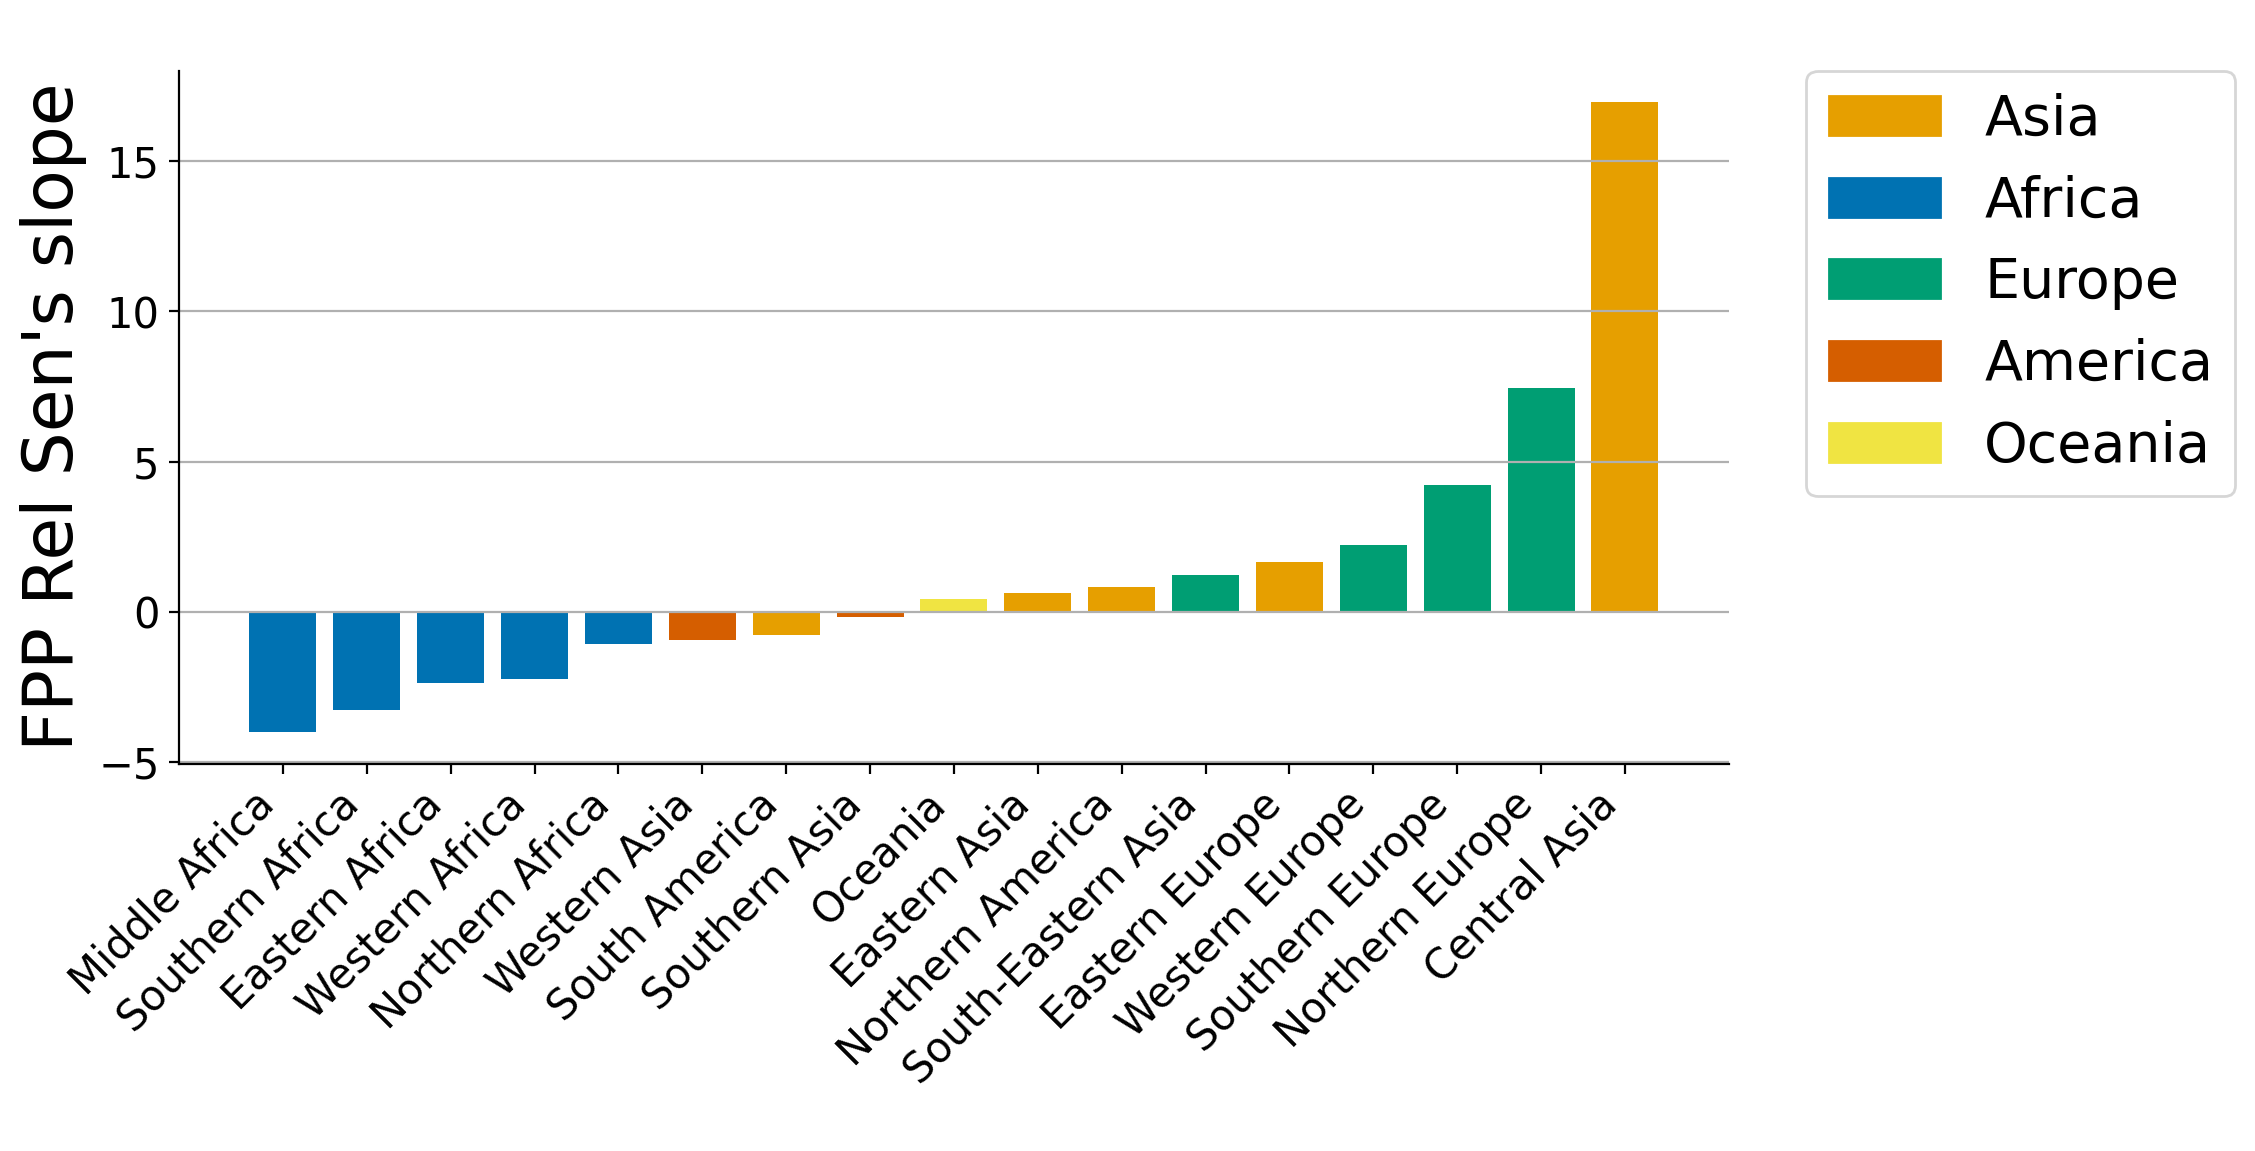

In [35]:
# Plotting the bar plot
f, ax = plt.subplots(figsize=(10, 4.5))
ax = set_font(ax, 15)
plt.bar(results_df1['Region'], results_df1['Slope'], color=colors)
# Adding labels and title
plt.xlabel(' ')
plt.ylabel('FPP Rel '+"Sen's slope", size=25)
plt.title(' ', size=16)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Creating legend patches
patches = [mpatches.Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
# Adding the legend outside the plot
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=20)
plt.xticks(rotation=45, ha='right');

In [43]:
del dfALL_slopes

In [44]:
results_df1 = results_df1.rename(columns={'Slope': 'Sen'})
dfALL_slopes = pd.merge(results_df1, results_df, on='Region')
dfALL_slopes

,Region,Sen,p-value,Significance,Trend,Intercept,Slope
0,Middle Africa,-4.002006,0.000083,***,decreasing,-1.299908,-39.562152
1,Southern Africa,-3.255300,0.000172,***,decreasing,8.392878,-27.987757
2,Eastern Africa,-2.370563,0.000083,***,decreasing,6.425011,-19.873924
3,Western Africa,-2.224639,0.000083,***,decreasing,4.784478,-19.421238
4,Northern Africa,-1.063717,0.000347,***,decreasing,2.882460,-14.028510
5,Western Asia,-0.946154,0.107405,ns,no trend,5.071726,-4.010092
6,South America,-0.757252,0.000347,***,decreasing,0.412692,-8.361754
7,Southern Asia,-0.175789,0.858028,ns,no trend,12.432647,17.401502
8,Oceania,0.425313,0.004208,**,increasing,-0.257212,4.863016
9,Eastern Asia,0.614578,0.000677,***,increasing,-1.872601,4.978176


Text(0, 0.5, "Sen's Slope")

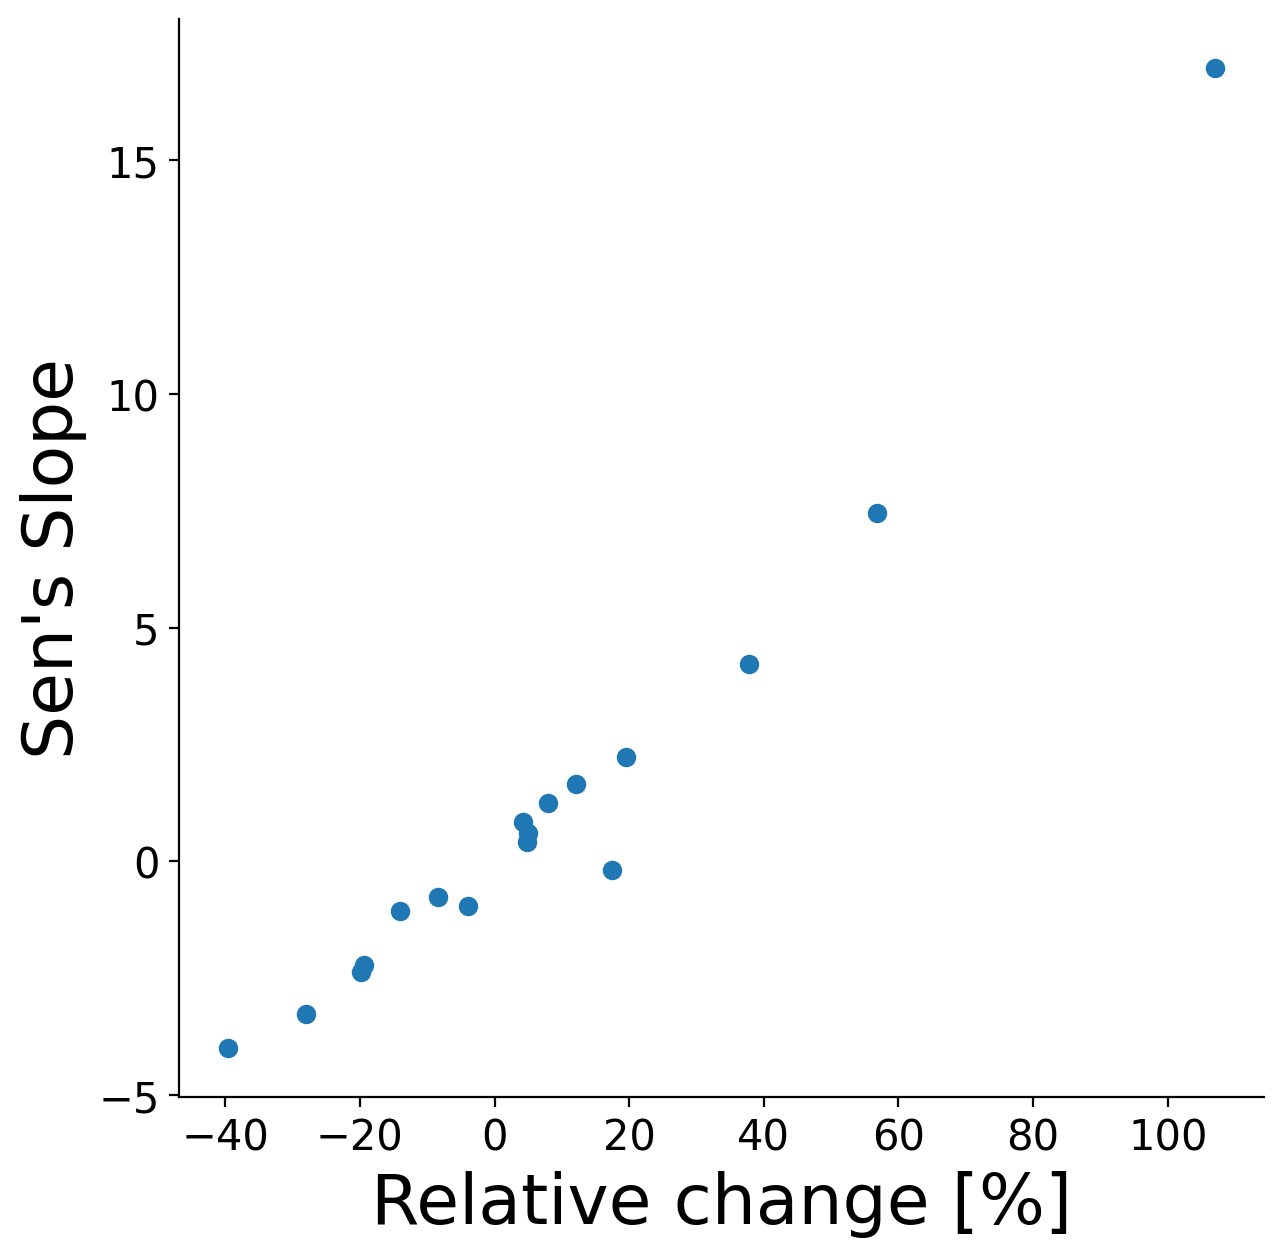

In [45]:
f, ax = plt.subplots(figsize=(7, 7))
ax = set_font(ax, 15)
plt.scatter(dfALL_slopes['Slope'], dfALL_slopes['Sen'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xlabel('Relative change [%]', size=25)
plt.ylabel("Sen's Slope", size=25)

In [46]:
fout = '../Figures/ComparisonSenRelchangeOK.pdf'
f.savefig(fout, dpi=300, bbox_inches='tight')